In [ ]:
# coding: utf-8

# SaaS Customer Churn Prediction & Retention Analytics

## Notebook 1: Data Exploration & Feature Engineering

**Author:** Poorna Venkat Neelakantam  
**Dataset:** RavenStack SaaS Platform (by River @ Rivalytics)  
**Objective:** Explore, clean, engineer features, and prepare data for ML modeling

---

## 1. Setup & Data Loading

**WHY:** Before any analysis, we need to load all data sources and understand 
what we're working with — shapes, types, nulls, distributions. Skipping this 
step is how analysts make costly mistakes downstream.

### 1.1 Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print("Libraries loaded successfully!")

Libraries loaded successfully!


### 1.2 Load the Master Dataset (from SQL Query 16 export)

**BUSINESS QUESTION:** Can we consolidate all customer data into a single 
analysis-ready table?

**HOW:** We exported Query 16 from PostgreSQL as CSV. This master table has 
1 row per account with all metrics pre-aggregated.

In [12]:
# UPDATE THIS PATH to where you saved your Query 16 CSV export
master_df = pd.read_csv('/Users/poornavenkat/Desktop/Data Analyasis /DataBricks_Alex/Raven_Stock/Output/CSV/Master_Data_Tableau.csv')

print(f"Shape: {master_df.shape[0]} rows × {master_df.shape[1]} columns")
print(f"\nColumns:\n{list(master_df.columns)}")

Shape: 748 rows × 36 columns

Columns:
['account_id', 'account_name', 'industry', 'country', 'signup_date', 'referral_source', 'plan_tier', 'seats', 'is_trial', 'churn_flag', 'subscription_count', 'latest_mrr', 'latest_arr', 'had_upgrade', 'had_downgrade', 'billing_frequency', 'auto_renew', 'distinct_features_used', 'total_usage_count', 'avg_usage_duration_secs', 'total_errors', 'beta_feature_events', 'total_tickets', 'avg_satisfaction', 'avg_resolution_hours', 'avg_first_response_min', 'critical_tickets', 'escalations', 'churn_date', 'reason_code', 'refund_amount_usd', 'preceding_upgrade_flag', 'preceding_downgrade_flag', 'is_reactivation', 'feedback_text', 'tenure_months']


### 1.3 Also load raw tables for validation & additional analysis

In [7]:
accounts = pd.read_csv('/Users/poornavenkat/Desktop/Data Analyasis /DataBricks_Alex/Raven_Stock/Raw/ravenstack_accounts.csv')
subscriptions = pd.read_csv('/Users/poornavenkat/Desktop/Data Analyasis /DataBricks_Alex/Raven_Stock/Raw/ravenstack_subscriptions.csv')
feature_usage = pd.read_csv('/Users/poornavenkat/Desktop/Data Analyasis /DataBricks_Alex/Raven_Stock/Raw/ravenstack_feature_usage.csv')
support_tickets = pd.read_csv('/Users/poornavenkat/Desktop/Data Analyasis /DataBricks_Alex/Raven_Stock/Raw/ravenstack_support_tickets.csv')
churn_events = pd.read_csv('/Users/poornavenkat/Desktop/Data Analyasis /DataBricks_Alex/Raven_Stock/Raw/ravenstack_churn_events.csv')

print(f"\n{'='*50}")
print(f"Raw Tables Loaded:")
print(f"  accounts:        {accounts.shape}")
print(f"  subscriptions:   {subscriptions.shape}")
print(f"  feature_usage:   {feature_usage.shape}")
print(f"  support_tickets: {support_tickets.shape}")
print(f"  churn_events:    {churn_events.shape}")
print(f"  TOTAL RECORDS:   {sum(df.shape[0] for df in [accounts, subscriptions, feature_usage, support_tickets, churn_events]):,}")




Raw Tables Loaded:
  accounts:        (500, 10)
  subscriptions:   (5000, 14)
  feature_usage:   (25000, 8)
  support_tickets: (2000, 9)
  churn_events:    (600, 9)
  TOTAL RECORDS:   33,100


## 2. Data Quality Assessment

**WHY:** Real-world data is MESSY. Nulls, wrong types, outliers — if we don't 
catch them here, our model will learn garbage. Every professional analyst starts 
with a data quality check. Interviewers ask: "How do you handle missing data?"

### 2.1 Data Types & Info

In [8]:
print("=== MASTER TABLE INFO ===\n")
print(master_df.dtypes)
print(f"\n{'='*50}")
print(f"Memory usage: {master_df.memory_usage(deep=True).sum() / 1024:.1f} KB")

=== MASTER TABLE INFO ===

account_id                   object
account_name                 object
industry                     object
country                      object
signup_date                  object
referral_source              object
plan_tier                    object
seats                         int64
is_trial                       bool
churn_flag                     bool
subscription_count            int64
latest_mrr                    int64
latest_arr                    int64
had_upgrade                   int64
had_downgrade                 int64
billing_frequency            object
auto_renew                    int64
distinct_features_used        int64
total_usage_count             int64
avg_usage_duration_secs     float64
total_errors                  int64
beta_feature_events           int64
total_tickets                 int64
avg_satisfaction            float64
avg_resolution_hours        float64
avg_first_response_min      float64
critical_tickets              int64
e

### 2.2 Missing Values Analysis

**BUSINESS QUESTION:** How much data is missing, and does missingness itself 
tell us something about customer behavior?

In [9]:
missing = master_df.isnull().sum()
missing_pct = (missing / len(master_df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)

print("=== MISSING VALUES (columns with nulls) ===\n")
print(missing_df[missing_df['Missing Count'] > 0].to_string())

=== MISSING VALUES (columns with nulls) ===

                          Missing Count  Missing %
feedback_text                       296      39.57
is_reactivation                     148      19.79
preceding_downgrade_flag            148      19.79
preceding_upgrade_flag              148      19.79
refund_amount_usd                   148      19.79
reason_code                         148      19.79
churn_date                          148      19.79


### 2.3 Visualize Missing Data Pattern

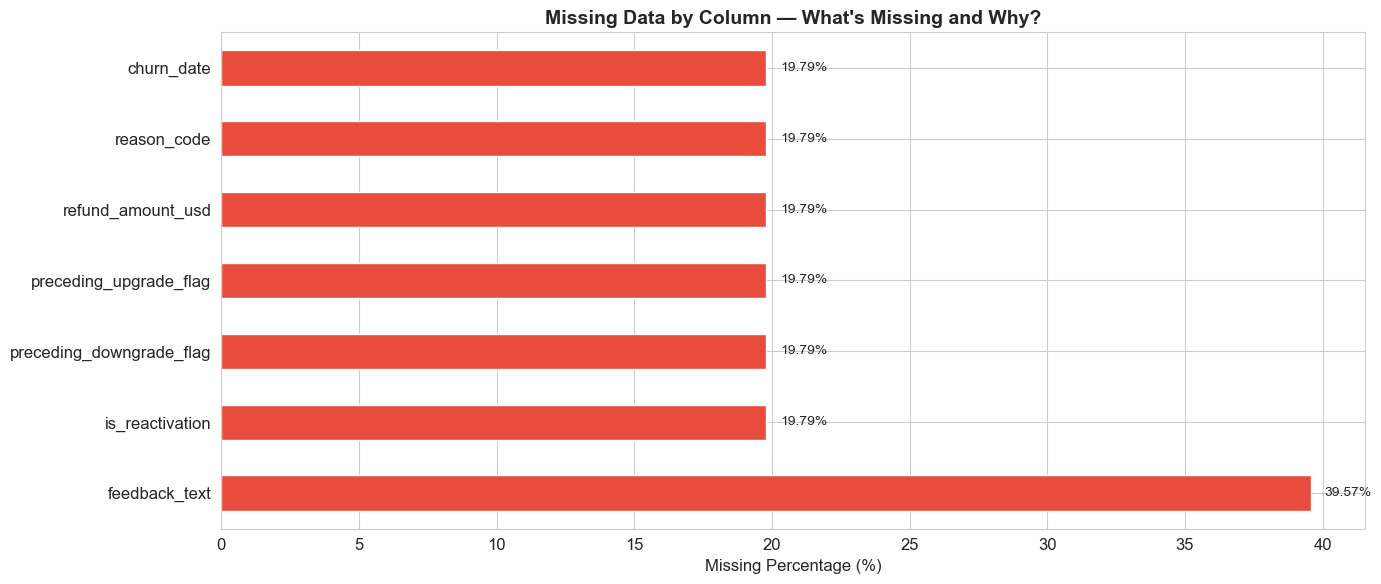

In [11]:
fig, ax = plt.subplots(figsize=(14, 6))
cols_with_missing = missing_df[missing_df['Missing Count'] > 0].index.tolist()
if cols_with_missing:
    missing_df[missing_df['Missing Count'] > 0]['Missing %'].plot(
        kind='barh', color='#e74c3c', ax=ax
    )
    ax.set_xlabel('Missing Percentage (%)')
    ax.set_title('Missing Data by Column — What\'s Missing and Why?', fontsize=14, fontweight='bold')
    for i, v in enumerate(missing_df[missing_df['Missing Count'] > 0]['Missing %']):
        ax.text(v + 0.5, i, f'{v}%', va='center', fontsize=10)
    plt.tight_layout()
    plt.savefig('/Users/poornavenkat/Desktop/Data Analyasis /DataBricks_Alex/Raven_Stock/Output/dashboards/01_missing_data.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No missing values found in the master table!")

### 2.4 Handle Missing Values

**HOW:** Different strategies for different columns:
- `churn_date`, `reason_code`, `feedback_text` → NULL for retained customers (expected, not an error)
- `avg_satisfaction` → 0 means no survey response (impute with median of non-zero)
- Numeric columns → Fill with 0 where appropriate

In [13]:
# Churn-specific columns: NULL is expected for retained customers — leave as-is
# They'll be excluded from churn-specific analysis

# For satisfaction: separate "no response" from actual scores
if 'avg_satisfaction' in master_df.columns:
    median_sat = master_df.loc[master_df['avg_satisfaction'] > 0, 'avg_satisfaction'].median()
    print(f"Median satisfaction (non-zero): {median_sat}")
    # Flag accounts with no satisfaction data
    master_df['has_satisfaction_data'] = (master_df['avg_satisfaction'] > 0).astype(int)

# Fill remaining numeric nulls with 0
numeric_cols = master_df.select_dtypes(include=[np.number]).columns
master_df[numeric_cols] = master_df[numeric_cols].fillna(0)

print(f"\nRemaining nulls after imputation: {master_df[numeric_cols].isnull().sum().sum()}")

# ---

Median satisfaction (non-zero): 2.4

Remaining nulls after imputation: 0


## 3. Univariate Analysis — Understanding Each Variable

**WHY:** Before looking at relationships, understand each variable on its own.
Distributions reveal outliers, skewness, and data quality issues that affect 
model performance. This is what interviewers mean by "tell me about your EDA process."

### 3.1 Target Variable: Churn Distribution

**BUSINESS QUESTION:** What percentage of our customer base has churned?

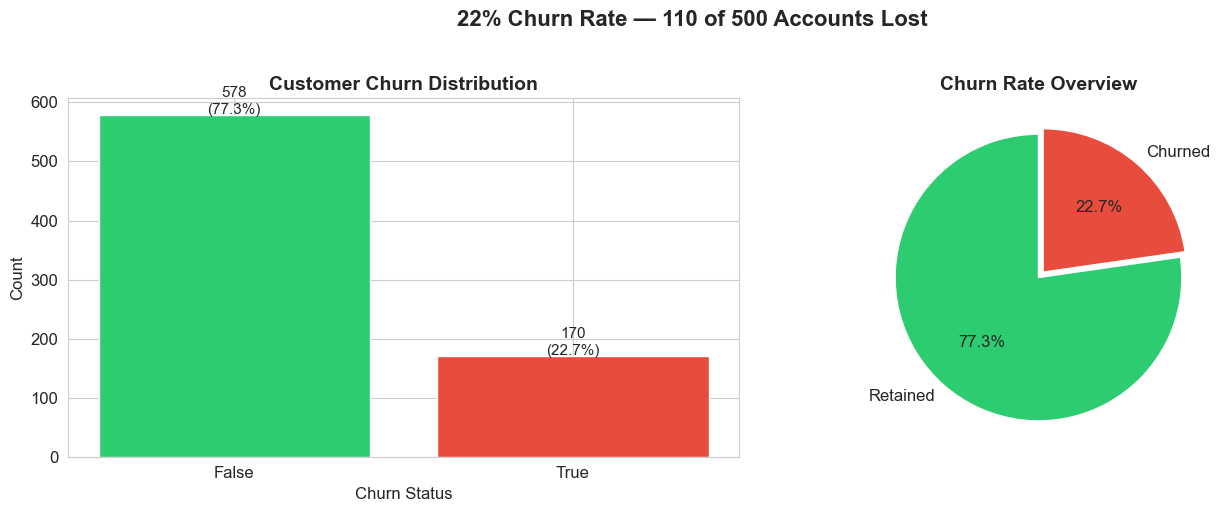

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
churn_counts = master_df['churn_flag'].value_counts()
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(churn_counts.index.astype(str), churn_counts.values, color=colors)
axes[0].set_title('Customer Churn Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Churn Status')
axes[0].set_ylabel('Count')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 3, f'{v}\n({v/len(master_df)*100:.1f}%)', ha='center', fontsize=11)

# Pie chart
axes[1].pie(churn_counts.values, labels=['Retained', 'Churned'], colors=colors,
            autopct='%1.1f%%', startangle=90, textprops={'fontsize': 12},
            explode=(0, 0.05))
axes[1].set_title('Churn Rate Overview', fontsize=14, fontweight='bold')

plt.suptitle('22% Churn Rate — 110 of 500 Accounts Lost', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/Users/poornavenkat/Desktop/Data Analyasis /DataBricks_Alex/Raven_Stock/Output/dashboards/02_churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.2 Numeric Variables Distribution

**BUSINESS QUESTION:** What do the distributions of revenue, usage, and support 
metrics look like? Are there outliers we need to handle?

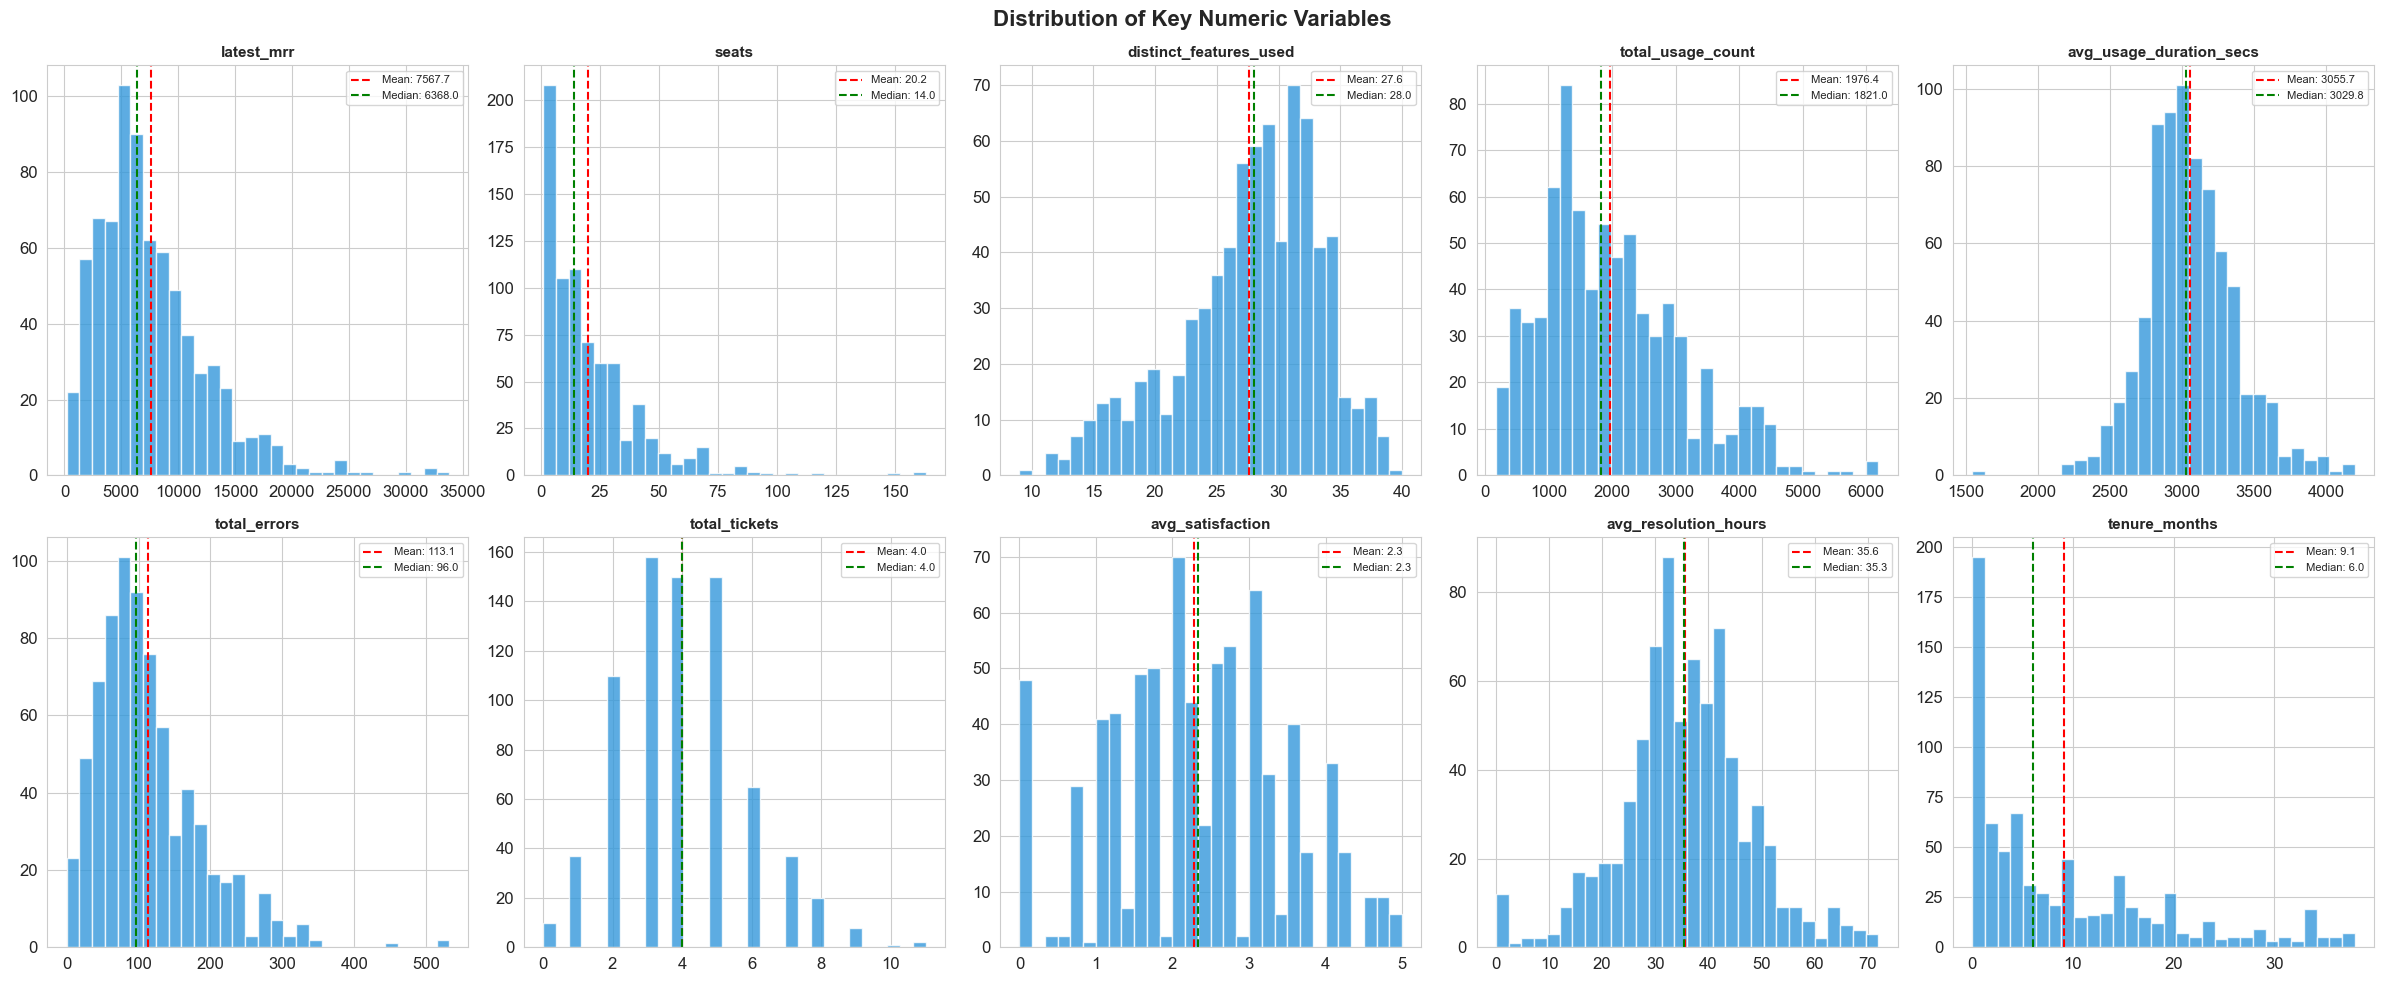

In [15]:
key_numeric = ['latest_mrr', 'seats', 'distinct_features_used', 'total_usage_count',
               'avg_usage_duration_secs', 'total_errors', 'total_tickets', 
               'avg_satisfaction', 'avg_resolution_hours', 'tenure_months']

# Filter to columns that exist in the master table
key_numeric = [col for col in key_numeric if col in master_df.columns]

fig, axes = plt.subplots(2, 5, figsize=(24, 10))
axes = axes.flatten()

for i, col in enumerate(key_numeric):
    master_df[col].hist(bins=30, ax=axes[i], color='#3498db', edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].axvline(master_df[col].mean(), color='red', linestyle='--', label=f'Mean: {master_df[col].mean():.1f}')
    axes[i].axvline(master_df[col].median(), color='green', linestyle='--', label=f'Median: {master_df[col].median():.1f}')
    axes[i].legend(fontsize=8)

# Hide unused subplots
for j in range(len(key_numeric), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of Key Numeric Variables', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('/Users/poornavenkat/Desktop/Data Analyasis /DataBricks_Alex/Raven_Stock/Output/dashboards/03_numeric_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.3 Categorical Variables Distribution

**BUSINESS QUESTION:** How are customers distributed across plans, industries, 
countries, and referral channels?

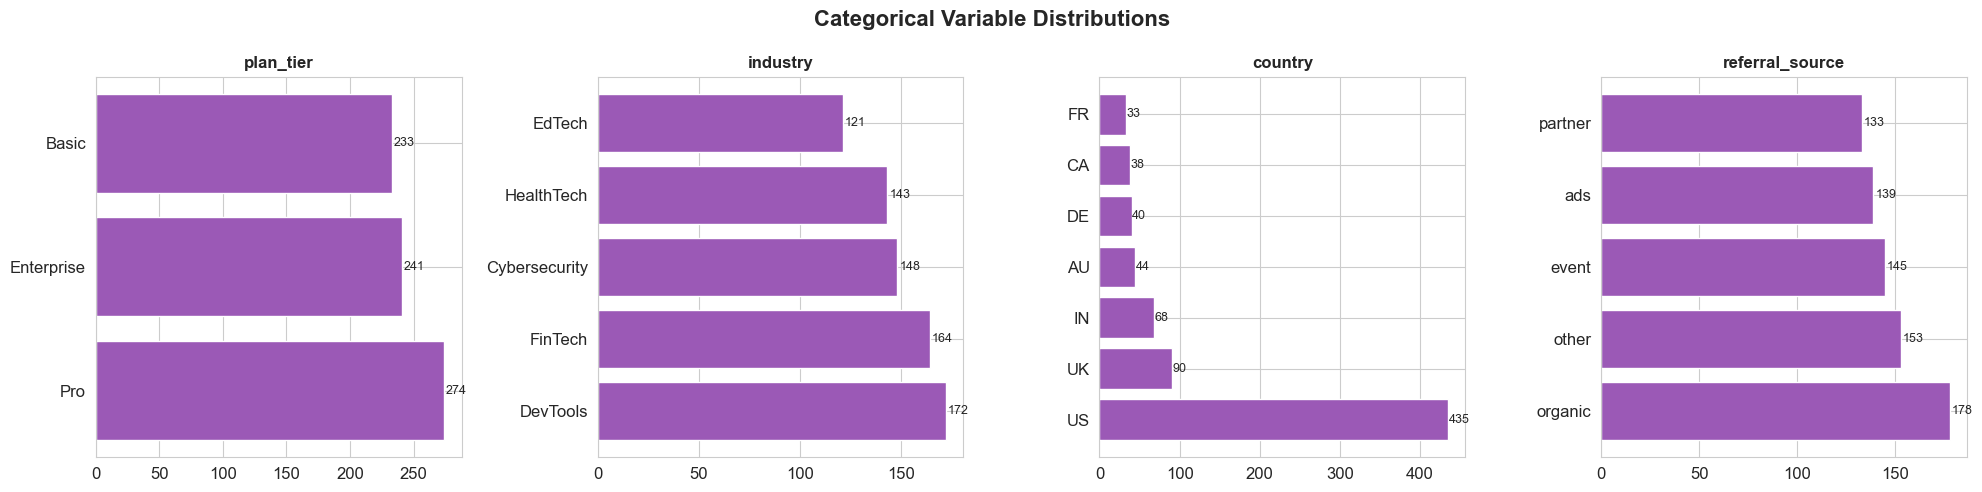

In [16]:
cat_cols = ['plan_tier', 'industry', 'country', 'referral_source']
cat_cols = [col for col in cat_cols if col in master_df.columns]

fig, axes = plt.subplots(1, len(cat_cols), figsize=(20, 5))

for i, col in enumerate(cat_cols):
    data = master_df[col].value_counts()
    axes[i].barh(data.index, data.values, color='#9b59b6', edgecolor='white')
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    for j, v in enumerate(data.values):
        axes[i].text(v + 1, j, str(v), va='center', fontsize=9)

plt.suptitle('Categorical Variable Distributions', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('/Users/poornavenkat/Desktop/Data Analyasis /DataBricks_Alex/Raven_Stock/Output/dashboards/04_categorical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

# ---

## 4. Bivariate Analysis — Churn vs Everything

**WHY:** This is the CORE of EDA for churn analysis. We compare every metric 
between churned and retained customers. The patterns we find here directly 
inform our ML features and business recommendations.



### 4.1 Churn Rate by Plan Tier

**BUSINESS QUESTION:** Are customers on Basic plans churning more than Enterprise?

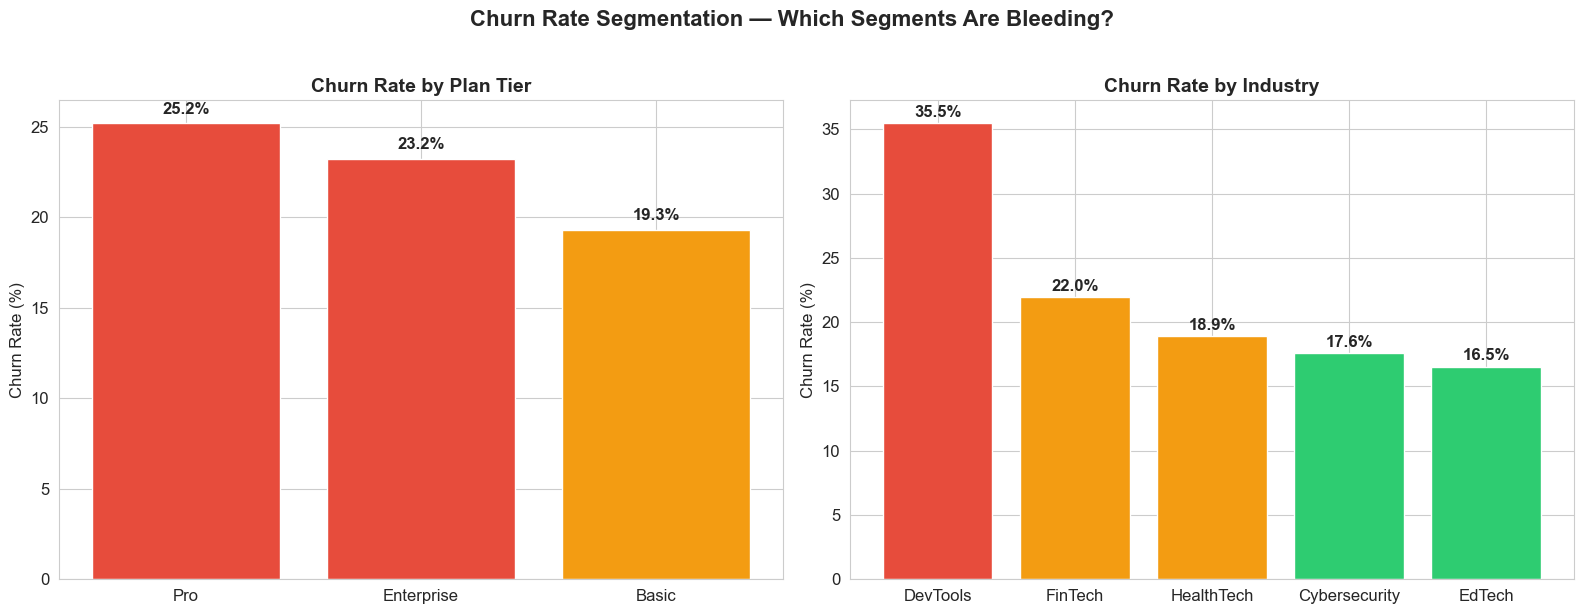

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Churn rate by plan
if 'plan_tier' in master_df.columns:
    churn_by_plan = master_df.groupby('plan_tier')['churn_flag'].apply(
        lambda x: (x == True).sum() / len(x) * 100 if x.dtype == bool 
        else (x == 'True').sum() / len(x) * 100 if x.dtype == object
        else x.sum() / len(x) * 100
    ).sort_values(ascending=False)
    
    colors_plan = ['#e74c3c' if v > 20 else '#f39c12' if v > 15 else '#2ecc71' for v in churn_by_plan.values]
    axes[0].bar(churn_by_plan.index, churn_by_plan.values, color=colors_plan, edgecolor='white')
    axes[0].set_title('Churn Rate by Plan Tier', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('Churn Rate (%)')
    for i, v in enumerate(churn_by_plan.values):
        axes[0].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=12, fontweight='bold')

# Churn rate by industry
if 'industry' in master_df.columns:
    churn_by_industry = master_df.groupby('industry')['churn_flag'].apply(
        lambda x: (x == True).sum() / len(x) * 100 if x.dtype == bool 
        else (x == 'True').sum() / len(x) * 100 if x.dtype == object
        else x.sum() / len(x) * 100
    ).sort_values(ascending=False)
    
    colors_ind = ['#e74c3c' if v > 22 else '#f39c12' if v > 18 else '#2ecc71' for v in churn_by_industry.values]
    axes[1].bar(churn_by_industry.index, churn_by_industry.values, color=colors_ind, edgecolor='white')
    axes[1].set_title('Churn Rate by Industry', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('Churn Rate (%)')
    for i, v in enumerate(churn_by_industry.values):
        axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=12, fontweight='bold')

plt.suptitle('Churn Rate Segmentation — Which Segments Are Bleeding?', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/Users/poornavenkat/Desktop/Data Analyasis /DataBricks_Alex/Raven_Stock/Output/dashboards/05_churn_by_segments.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.2 Churned vs Retained — Key Metrics Comparison

**BUSINESS QUESTION:** What behavioral differences exist between customers 
who stayed and those who left?

In [19]:
# Convert churn_flag to proper labels for grouping
master_df['churn_label'] = master_df['churn_flag'].apply(
    lambda x: 'Churned' if x in [True, 'True', 1] else 'Retained'
)

compare_cols = ['latest_mrr', 'seats', 'distinct_features_used', 'total_usage_count',
                'avg_usage_duration_secs', 'total_errors', 'total_tickets',
                'avg_satisfaction', 'avg_resolution_hours', 'critical_tickets',
                'escalations', 'beta_feature_events']

compare_cols = [col for col in compare_cols if col in master_df.columns]

comparison = master_df.groupby('churn_label')[compare_cols].mean().round(2).T
comparison['Difference'] = comparison['Churned'] - comparison['Retained']
comparison['Diff_%'] = ((comparison['Churned'] - comparison['Retained']) / comparison['Retained'] * 100).round(1)

print("=" * 70)
print("CHURNED vs RETAINED — Average Metric Comparison")
print("=" * 70)
print(comparison.to_string())
print("\n💡 INSIGHT: Positive Diff_% means churned customers have HIGHER values")
print("            Negative Diff_% means churned customers have LOWER values")

CHURNED vs RETAINED — Average Metric Comparison
churn_label              Churned  Retained  Difference  Diff_%
latest_mrr               7260.79   7657.92     -397.13    -5.2
seats                      19.65     20.39       -0.74    -3.6
distinct_features_used     27.68     27.60        0.08     0.3
total_usage_count        1941.72   1986.56      -44.84    -2.3
avg_usage_duration_secs  3042.31   3059.60      -17.29    -0.6
total_errors              106.62    114.96       -8.34    -7.3
total_tickets               3.94      4.02       -0.08    -2.0
avg_satisfaction            2.28      2.28        0.00     0.0
avg_resolution_hours       34.42     35.90       -1.48    -4.1
critical_tickets           87.96    102.38      -14.42   -14.1
escalations                11.92      9.65        2.27    23.5
beta_feature_events        19.46     20.24       -0.78    -3.9

💡 INSIGHT: Positive Diff_% means churned customers have HIGHER values
            Negative Diff_% means churned customers have LOWER

### 4.3 Box Plots — Churned vs Retained Side by Side

**BUSINESS QUESTION:** Are the differences between churned and retained 
customers statistically visible, or just noise?

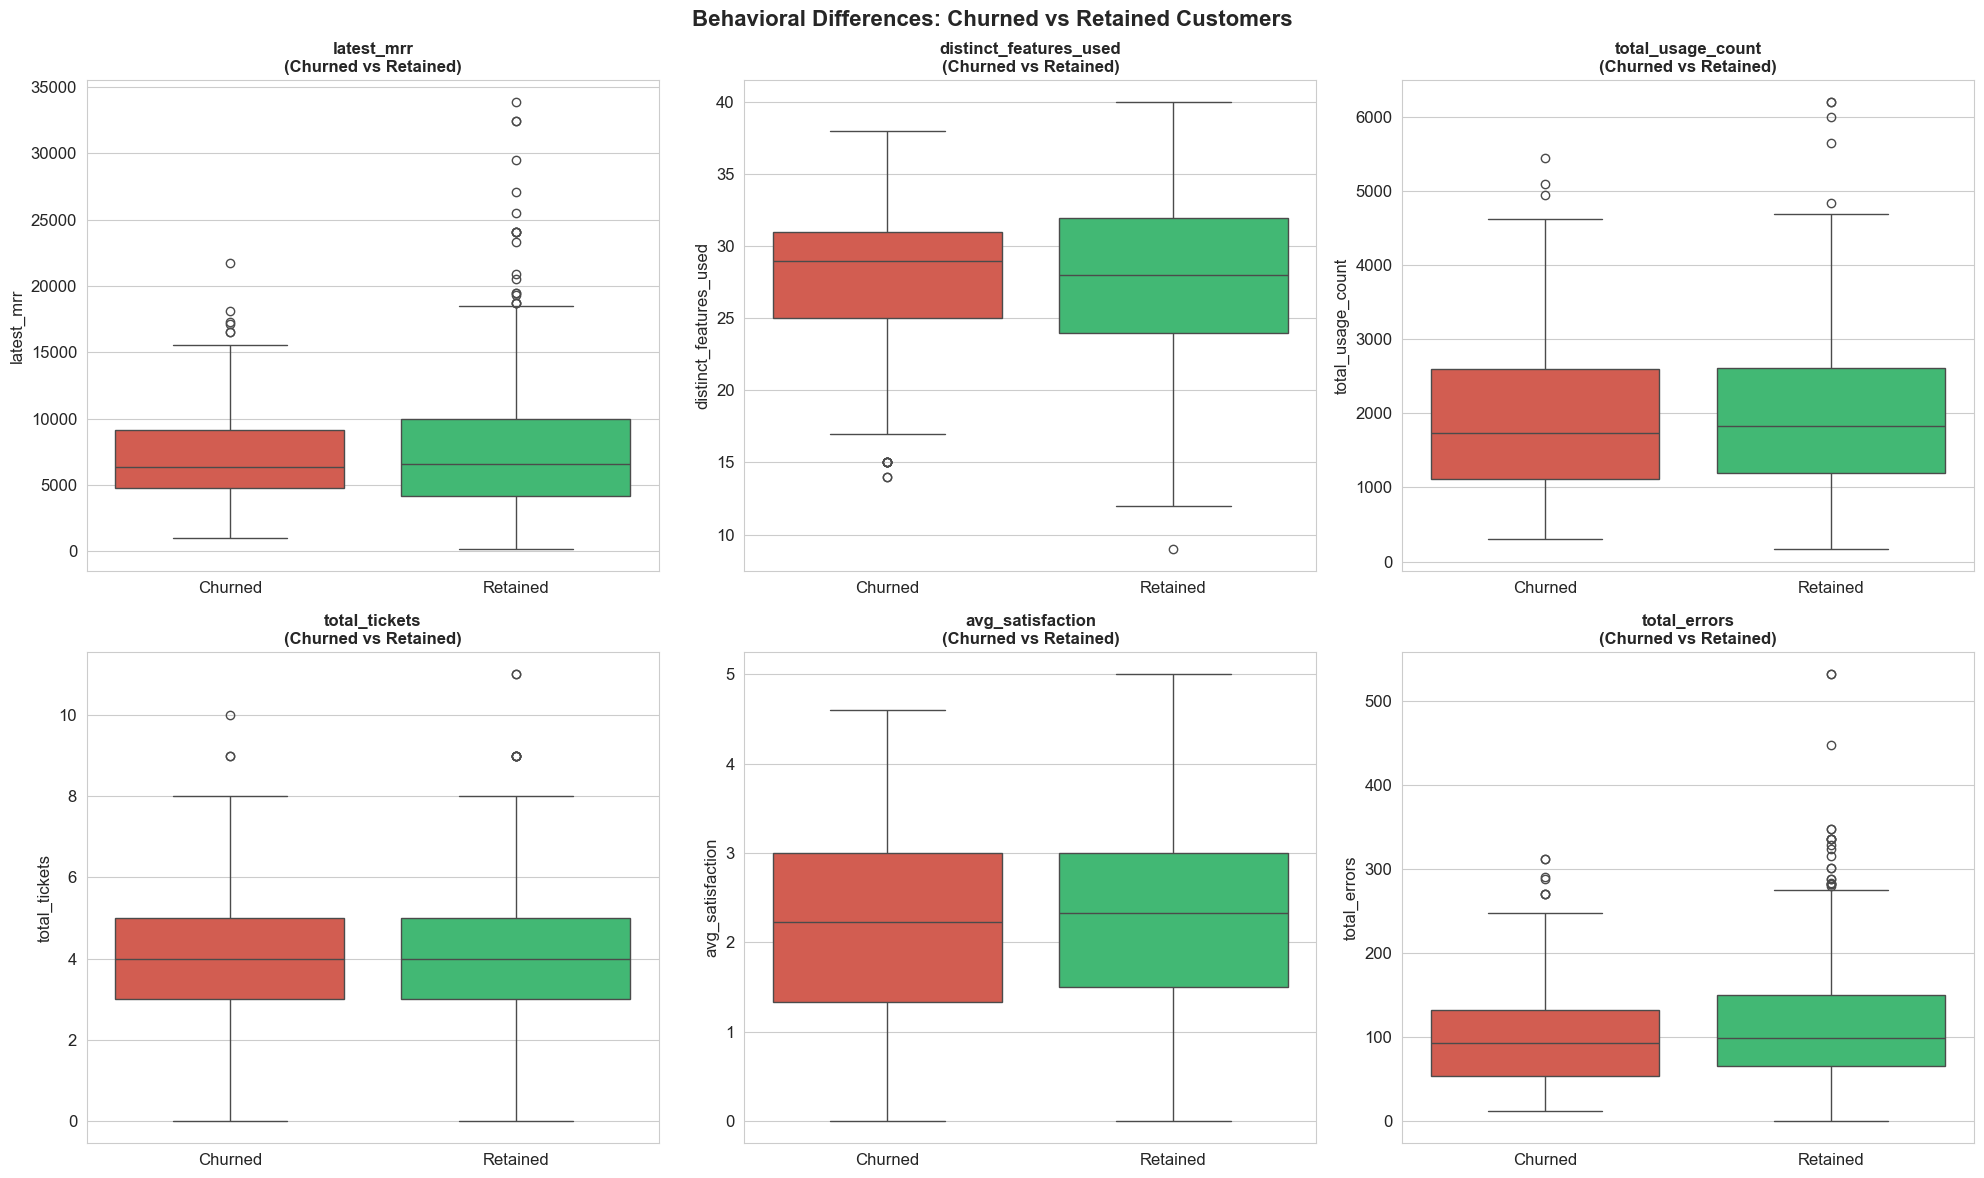

In [21]:
plot_cols = ['latest_mrr', 'distinct_features_used', 'total_usage_count', 
             'total_tickets', 'avg_satisfaction', 'total_errors']
plot_cols = [col for col in plot_cols if col in master_df.columns]

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for i, col in enumerate(plot_cols):
    sns.boxplot(data=master_df, x='churn_label', y=col, ax=axes[i],
                palette={'Retained': '#2ecc71', 'Churned': '#e74c3c'})
    axes[i].set_title(f'{col}\n(Churned vs Retained)', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')

for j in range(len(plot_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Behavioral Differences: Churned vs Retained Customers', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('/Users/poornavenkat/Desktop/Data Analyasis /DataBricks_Alex/Raven_Stock/Output/dashboards/06_churned_vs_retained_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.4 Churn Reason Analysis

**BUSINESS QUESTION:** Why are customers ACTUALLY leaving, and which reasons 
are costing us the most revenue?

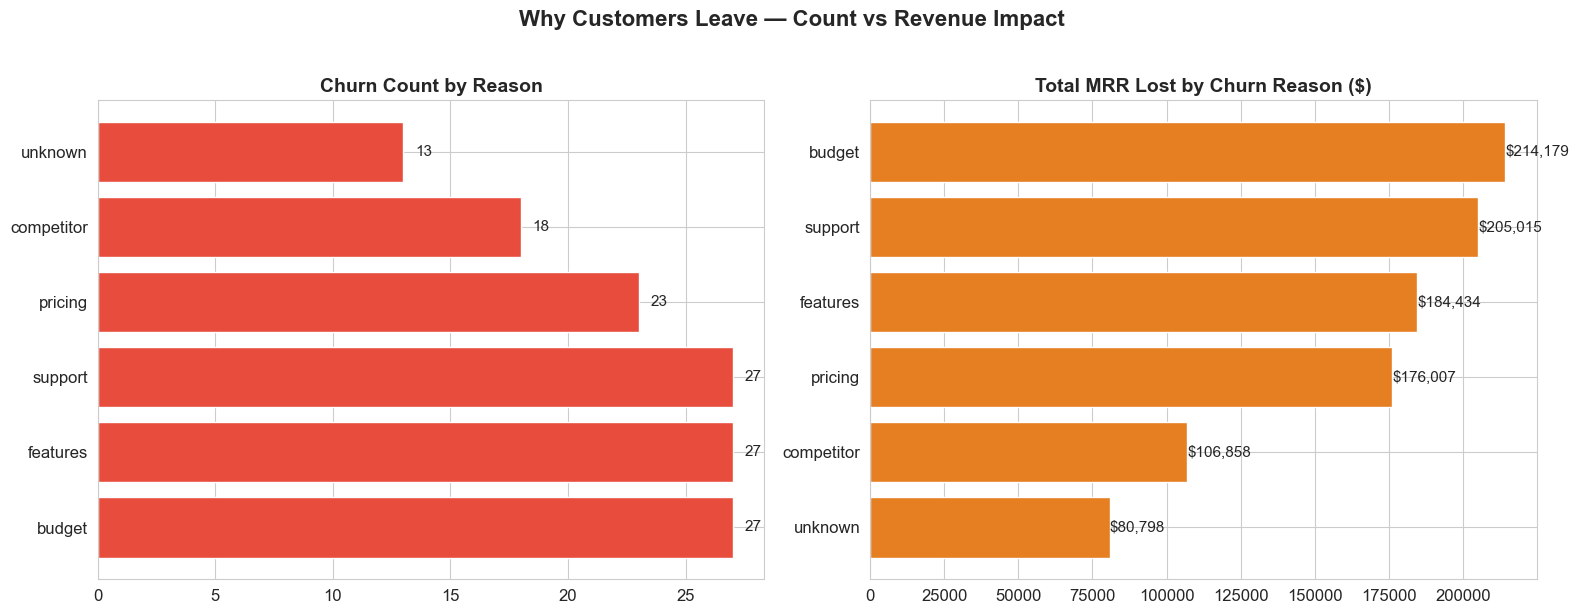

In [22]:
if 'reason_code' in master_df.columns:
    churned_df = master_df[master_df['churn_label'] == 'Churned']
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Count by reason
    reason_counts = churned_df['reason_code'].value_counts()
    axes[0].barh(reason_counts.index, reason_counts.values, color='#e74c3c', edgecolor='white')
    axes[0].set_title('Churn Count by Reason', fontsize=14, fontweight='bold')
    for i, v in enumerate(reason_counts.values):
        axes[0].text(v + 0.5, i, str(v), va='center', fontsize=11)
    
    # MRR lost by reason
    if 'latest_mrr' in master_df.columns:
        mrr_by_reason = churned_df.groupby('reason_code')['latest_mrr'].sum().sort_values(ascending=True)
        axes[1].barh(mrr_by_reason.index, mrr_by_reason.values, color='#e67e22', edgecolor='white')
        axes[1].set_title('Total MRR Lost by Churn Reason ($)', fontsize=14, fontweight='bold')
        for i, v in enumerate(mrr_by_reason.values):
            axes[1].text(v + 100, i, f'${v:,.0f}', va='center', fontsize=11)
    
    plt.suptitle('Why Customers Leave — Count vs Revenue Impact', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('/Users/poornavenkat/Desktop/Data Analyasis /DataBricks_Alex/Raven_Stock/Output/dashboards/07_churn_reasons.png', dpi=150, bbox_inches='tight')
    plt.show()

# ---

## 5. Correlation Analysis

**WHY:** Correlation heatmap reveals two critical things:
1. Which features correlate with churn (potential predictors)
2. Which features correlate with EACH OTHER (multicollinearity — bad for some models)

**BUSINESS QUESTION:** Which customer behaviors are most strongly associated 
with churn, and are any of our metrics redundant?

### 5.1 Correlation Heatmap

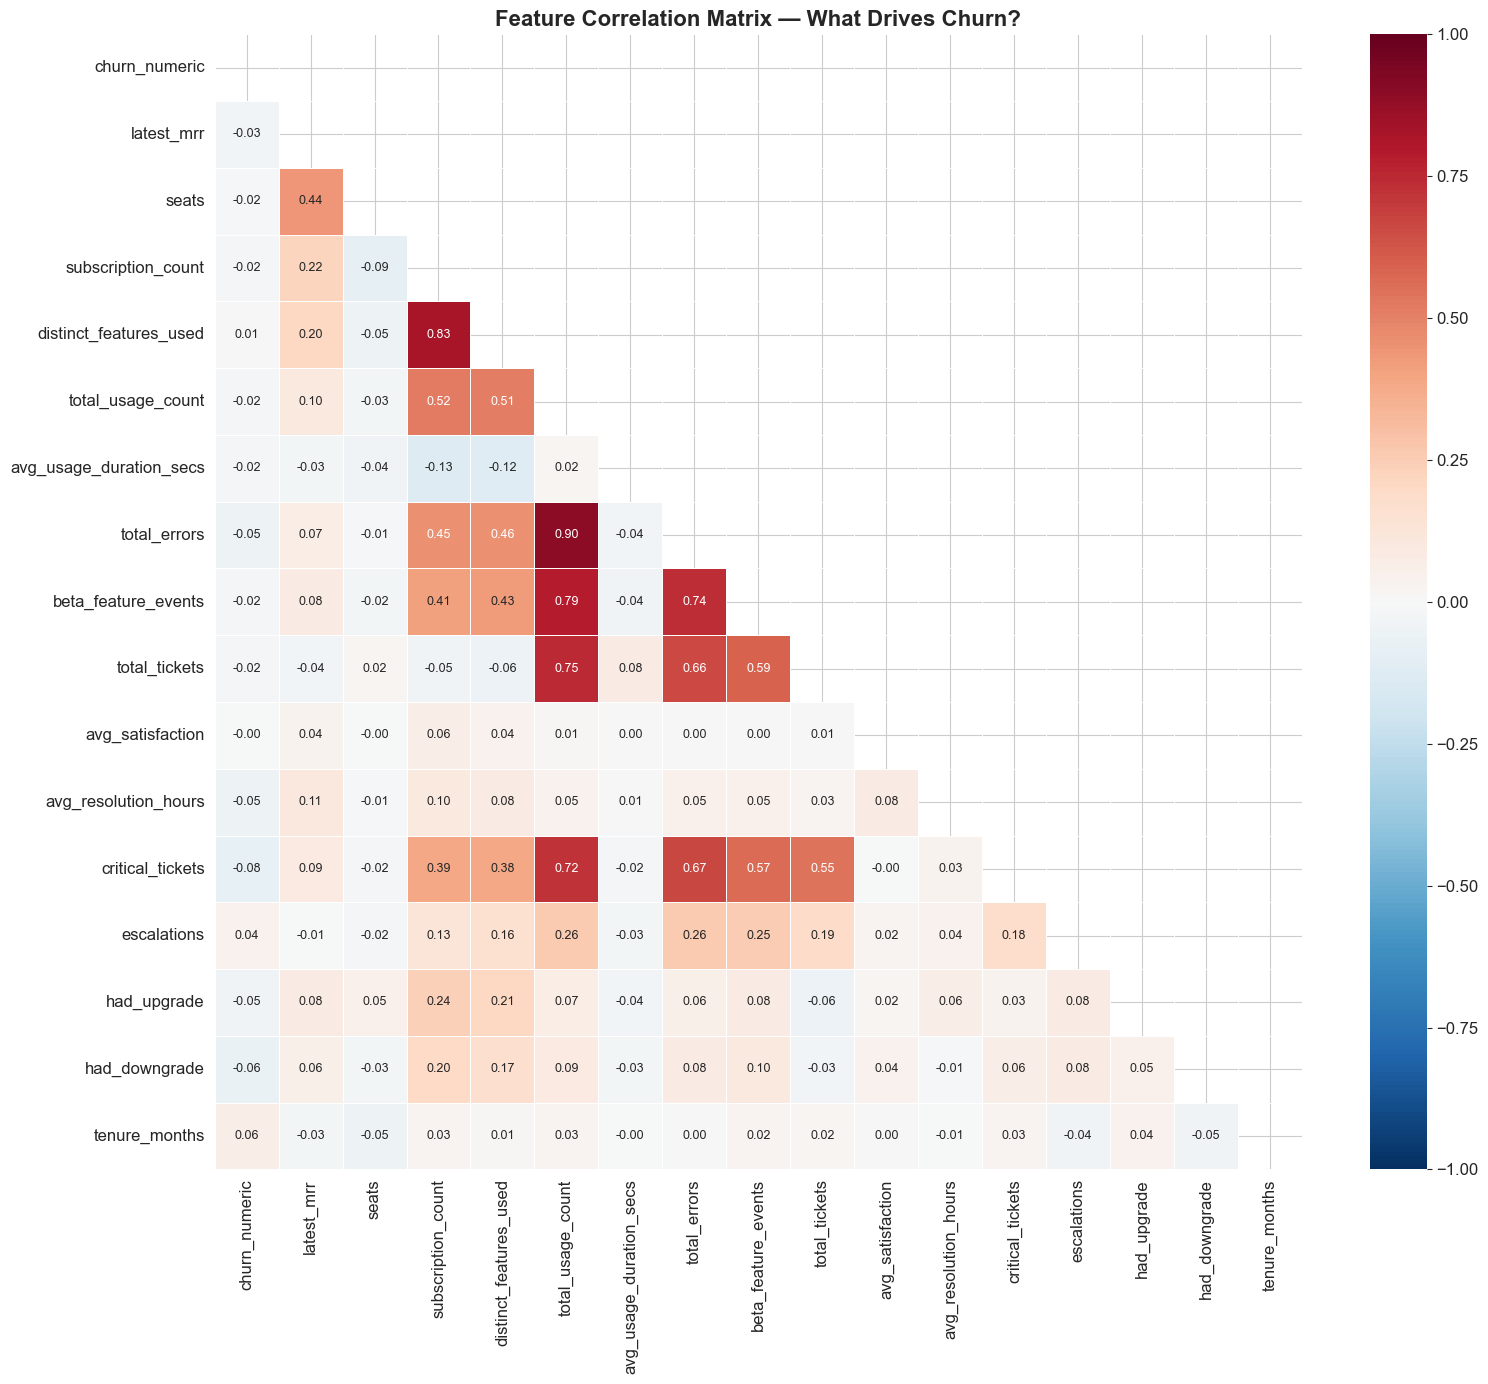

In [23]:
# Create numeric churn flag for correlation
master_df['churn_numeric'] = master_df['churn_label'].map({'Churned': 1, 'Retained': 0})

corr_cols = ['churn_numeric', 'latest_mrr', 'seats', 'subscription_count',
             'distinct_features_used', 'total_usage_count', 'avg_usage_duration_secs',
             'total_errors', 'beta_feature_events', 'total_tickets', 'avg_satisfaction',
             'avg_resolution_hours', 'critical_tickets', 'escalations',
             'had_upgrade', 'had_downgrade', 'tenure_months']

corr_cols = [col for col in corr_cols if col in master_df.columns]

corr_matrix = master_df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(16, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.5,
            annot_kws={'size': 9})
ax.set_title('Feature Correlation Matrix — What Drives Churn?', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('/Users/poornavenkat/Desktop/Data Analyasis /DataBricks_Alex/Raven_Stock/Output/dashboards/08_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.2 Top Correlations with Churn

TOP CORRELATIONS WITH CHURN
critical_tickets          -0.081732
tenure_months              0.064182
had_downgrade             -0.063007
avg_resolution_hours      -0.051376
total_errors              -0.048026
had_upgrade               -0.045010
escalations                0.042274
latest_mrr                -0.034369
avg_usage_duration_secs   -0.023029
beta_feature_events       -0.022985
total_tickets             -0.020036
total_usage_count         -0.017227
subscription_count        -0.016129
seats                     -0.015216
distinct_features_used     0.005495
avg_satisfaction          -0.000455

💡 Positive = higher value → more likely to churn
   Negative = higher value → less likely to churn


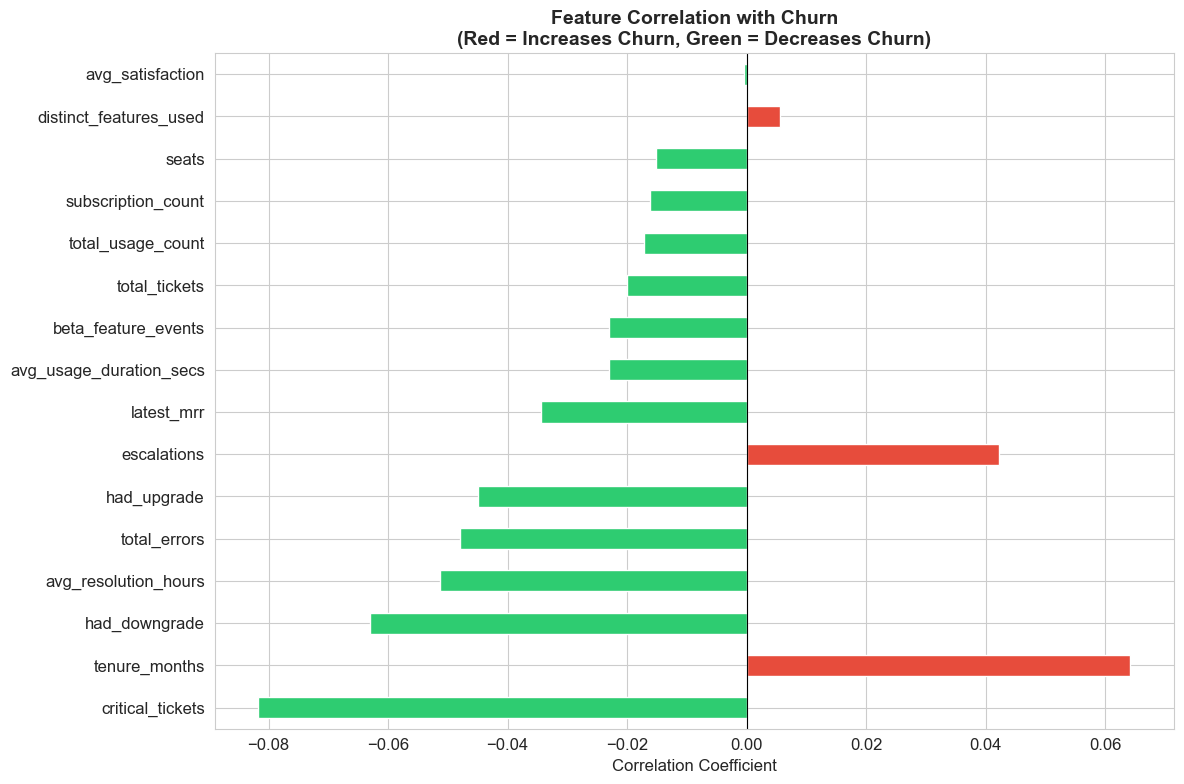

In [24]:
churn_corr = corr_matrix['churn_numeric'].drop('churn_numeric').sort_values(key=abs, ascending=False)

print("=" * 50)
print("TOP CORRELATIONS WITH CHURN")
print("=" * 50)
print(churn_corr.to_string())
print("\n💡 Positive = higher value → more likely to churn")
print("   Negative = higher value → less likely to churn")

fig, ax = plt.subplots(figsize=(12, 8))
colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in churn_corr.values]
churn_corr.plot(kind='barh', color=colors, ax=ax, edgecolor='white')
ax.set_title('Feature Correlation with Churn\n(Red = Increases Churn, Green = Decreases Churn)', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Correlation Coefficient')
ax.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('/Users/poornavenkat/Desktop/Data Analyasis /DataBricks_Alex/Raven_Stock/Output/dashboards/09_churn_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

# ---

## 6. Feature Engineering

**WHY:** Raw data is rarely enough for a good ML model. Feature engineering 
creates NEW variables that capture business logic the model can't discover on 
its own. This is the #1 skill that separates junior from senior analysts.



### 6.1 Create Derived Features

In [25]:
print("=== ENGINEERING NEW FEATURES ===\n")

# 1. MRR per seat — value perception metric
if 'latest_mrr' in master_df.columns and 'seats' in master_df.columns:
    master_df['mrr_per_seat'] = (master_df['latest_mrr'] / master_df['seats'].replace(0, 1)).round(2)
    print("✅ mrr_per_seat = MRR / seats (value perception)")

# 2. High priority ticket ratio
if 'critical_tickets' in master_df.columns and 'total_tickets' in master_df.columns:
    master_df['critical_ticket_ratio'] = (
        master_df['critical_tickets'] / master_df['total_tickets'].replace(0, 1)
    ).round(4)
    print("✅ critical_ticket_ratio = critical tickets / total tickets")

# 3. Error rate per usage event
if 'total_errors' in master_df.columns and 'total_usage_count' in master_df.columns:
    master_df['error_rate'] = (
        master_df['total_errors'] / master_df['total_usage_count'].replace(0, 1)
    ).round(4)
    print("✅ error_rate = errors / usage events (product quality)")

# 4. Beta adoption ratio
if 'beta_feature_events' in master_df.columns and 'total_usage_count' in master_df.columns:
    master_df['beta_adoption_ratio'] = (
        master_df['beta_feature_events'] / master_df['total_usage_count'].replace(0, 1)
    ).round(4)
    print("✅ beta_adoption_ratio = beta events / total events")

# 5. Support intensity — tickets per month of tenure
if 'total_tickets' in master_df.columns and 'tenure_months' in master_df.columns:
    master_df['tickets_per_month'] = (
        master_df['total_tickets'] / master_df['tenure_months'].replace(0, 1)
    ).round(4)
    print("✅ tickets_per_month = total tickets / tenure months")

# 6. Usage intensity — features per month
if 'distinct_features_used' in master_df.columns and 'tenure_months' in master_df.columns:
    master_df['features_per_month'] = (
        master_df['distinct_features_used'] / master_df['tenure_months'].replace(0, 1)
    ).round(4)
    print("✅ features_per_month = distinct features / tenure months")

# 7. Is Enterprise flag
if 'plan_tier' in master_df.columns:
    master_df['is_enterprise'] = (master_df['plan_tier'] == 'Enterprise').astype(int)
    print("✅ is_enterprise = binary flag for Enterprise tier")

# 8. Is US customer flag
if 'country' in master_df.columns:
    master_df['is_us'] = (master_df['country'] == 'US').astype(int)
    print("✅ is_us = binary flag for US-based customers")

# 9. Has support interaction
if 'total_tickets' in master_df.columns:
    master_df['has_support_interaction'] = (master_df['total_tickets'] > 0).astype(int)
    print("✅ has_support_interaction = any support tickets filed")

# 10. Engagement score (composite)
if all(col in master_df.columns for col in ['distinct_features_used', 'total_usage_count', 'avg_usage_duration_secs']):
    from sklearn.preprocessing import MinMaxScaler
    scaler = MinMaxScaler()
    engagement_cols = ['distinct_features_used', 'total_usage_count', 'avg_usage_duration_secs']
    scaled = scaler.fit_transform(master_df[engagement_cols])
    master_df['engagement_score'] = scaled.mean(axis=1).round(4)
    print("✅ engagement_score = normalized composite of features × usage × duration")

print(f"\n📊 Total features after engineering: {master_df.shape[1]}")

=== ENGINEERING NEW FEATURES ===

✅ mrr_per_seat = MRR / seats (value perception)
✅ critical_ticket_ratio = critical tickets / total tickets
✅ error_rate = errors / usage events (product quality)
✅ beta_adoption_ratio = beta events / total events
✅ tickets_per_month = total tickets / tenure months
✅ features_per_month = distinct features / tenure months
✅ is_enterprise = binary flag for Enterprise tier
✅ is_us = binary flag for US-based customers
✅ has_support_interaction = any support tickets filed
✅ engagement_score = normalized composite of features × usage × duration

📊 Total features after engineering: 49


### 6.2 Verify New Features

In [26]:
new_features = ['mrr_per_seat', 'critical_ticket_ratio', 'error_rate', 
                'beta_adoption_ratio', 'tickets_per_month', 'features_per_month',
                'is_enterprise', 'is_us', 'has_support_interaction', 'engagement_score']

new_features = [f for f in new_features if f in master_df.columns]

print("\n=== NEW FEATURES SUMMARY ===\n")
print(master_df[new_features].describe().round(4).to_string())


=== NEW FEATURES SUMMARY ===

       mrr_per_seat  critical_ticket_ratio  error_rate  beta_adoption_ratio  tickets_per_month  features_per_month  is_enterprise     is_us  has_support_interaction  engagement_score
count      748.0000               748.0000    748.0000             748.0000           748.0000            748.0000       748.0000  748.0000                 748.0000          748.0000
mean      1181.6378                24.7999      0.0568               0.0101             1.5192             10.5597         0.3222    0.5816                   0.9866            0.4899
std       2085.2864                16.8757      0.0154               0.0044             1.7967             11.0516         0.4676    0.4936                   0.1149            0.1094
min         19.0000                 0.0000      0.0000               0.0000             0.0000              0.3243         0.0000    0.0000                   0.0000            0.0462
25%        199.0000                12.8000      0.0460

### 6.3 New Features vs Churn

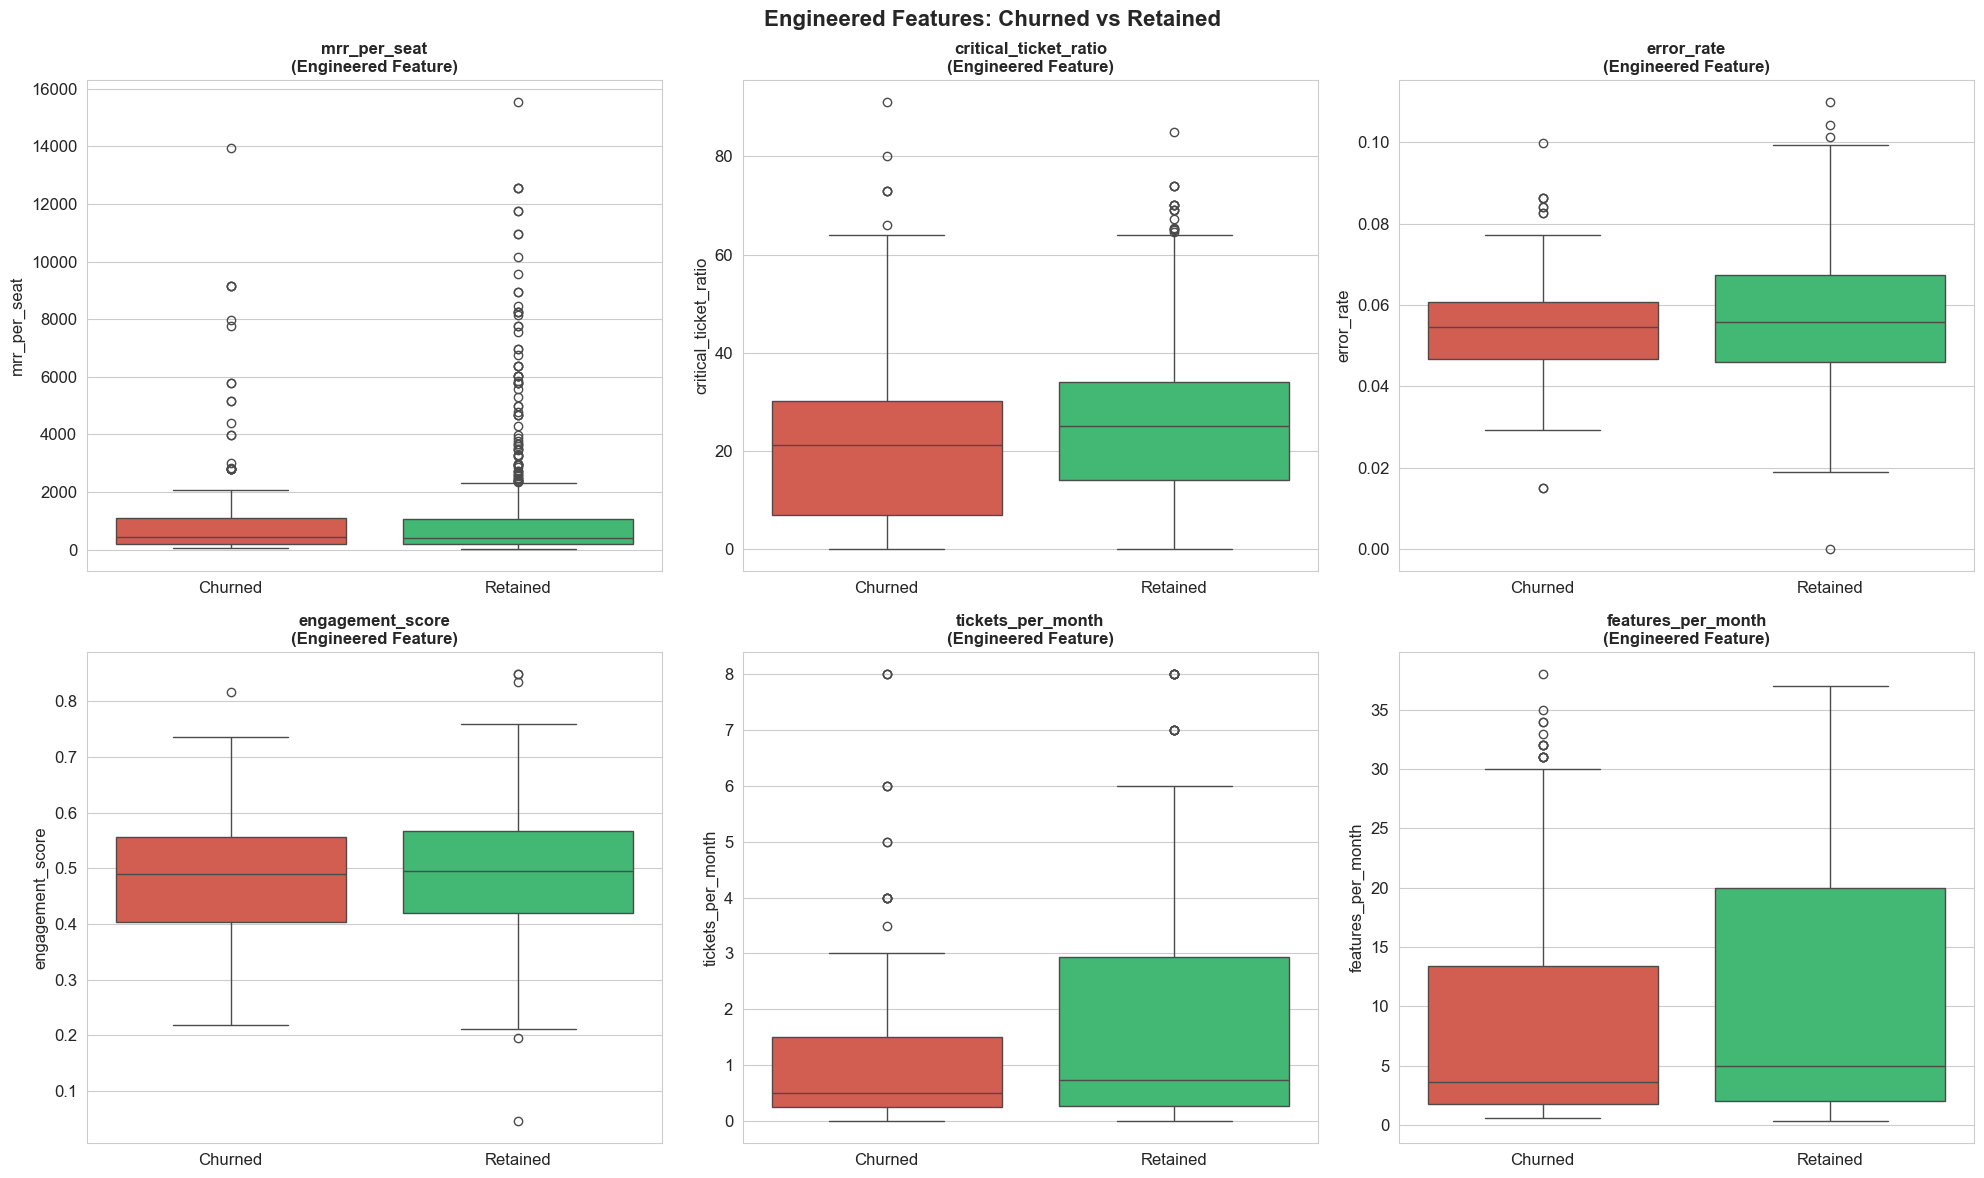

In [29]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

plot_new = ['mrr_per_seat', 'critical_ticket_ratio', 'error_rate',
            'engagement_score', 'tickets_per_month', 'features_per_month']
plot_new = [f for f in plot_new if f in master_df.columns]

for i, col in enumerate(plot_new):
    sns.boxplot(data=master_df, x='churn_label', y=col, ax=axes[i],
                palette={'Retained': '#2ecc71', 'Churned': '#e74c3c'})
    axes[i].set_title(f'{col}\n(Engineered Feature)', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')

for j in range(len(plot_new), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Engineered Features: Churned vs Retained', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('/Users/poornavenkat/Desktop/Data Analyasis /DataBricks_Alex/Raven_Stock/Output/dashboards/10_engineered_features_vs_churn.png', dpi=150, bbox_inches='tight')
plt.show()

# ---

## 7. Referral Source & Acquisition Channel Analysis

**BUSINESS QUESTION:** Which customer acquisition channels bring high-value 
customers who actually STAY?

=== REFERRAL SOURCE EFFECTIVENESS ===

                 total_accounts  churned  churn_rate  avg_mrr  avg_tenure  avg_engagement
referral_source                                                                          
event                       145       50        34.0  7069.02        8.86            0.48
other                       153       39        25.0  7096.20        9.12            0.50
ads                         139       32        23.0  7931.55       11.47            0.50
organic                     178       32        18.0  7492.96        7.60            0.49
partner                     133       17        13.0  8373.34        8.89            0.48


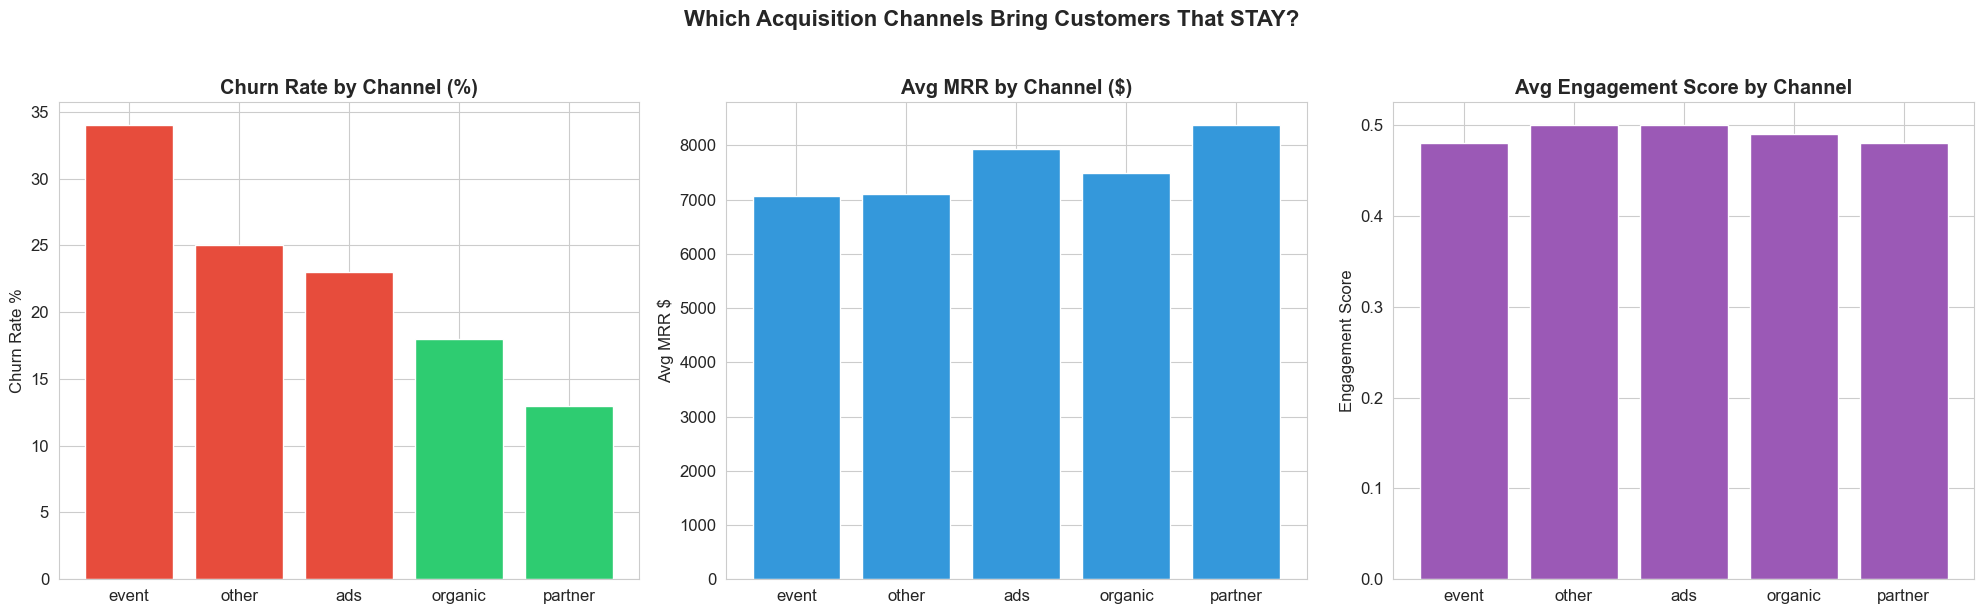

In [30]:
if 'referral_source' in master_df.columns:
    channel_analysis = master_df.groupby('referral_source').agg(
        total_accounts=('account_id', 'count'),
        churned=('churn_numeric', 'sum'),
        churn_rate=('churn_numeric', 'mean'),
        avg_mrr=('latest_mrr', 'mean'),
        avg_tenure=('tenure_months', 'mean'),
        avg_engagement=('engagement_score', 'mean') if 'engagement_score' in master_df.columns else ('churn_numeric', 'count')
    ).round(2)
    
    channel_analysis['churn_rate'] = (channel_analysis['churn_rate'] * 100).round(1)
    channel_analysis = channel_analysis.sort_values('churn_rate', ascending=False)
    
    print("=== REFERRAL SOURCE EFFECTIVENESS ===\n")
    print(channel_analysis.to_string())
    
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    
    axes[0].bar(channel_analysis.index, channel_analysis['churn_rate'], 
                color=['#e74c3c' if v > 22 else '#2ecc71' for v in channel_analysis['churn_rate']])
    axes[0].set_title('Churn Rate by Channel (%)', fontweight='bold')
    axes[0].set_ylabel('Churn Rate %')
    
    axes[1].bar(channel_analysis.index, channel_analysis['avg_mrr'], color='#3498db')
    axes[1].set_title('Avg MRR by Channel ($)', fontweight='bold')
    axes[1].set_ylabel('Avg MRR $')
    
    if 'avg_engagement' in channel_analysis.columns:
        axes[2].bar(channel_analysis.index, channel_analysis['avg_engagement'], color='#9b59b6')
        axes[2].set_title('Avg Engagement Score by Channel', fontweight='bold')
        axes[2].set_ylabel('Engagement Score')
    
    plt.suptitle('Which Acquisition Channels Bring Customers That STAY?', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('/Users/poornavenkat/Desktop/Data Analyasis /DataBricks_Alex/Raven_Stock/Output/dashboards/11_referral_source_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()

# ---

## 8. Export Cleaned & Engineered Dataset

**WHY:** Save the enriched dataset for:
1. Notebook 2: ML Model Training
2. Tableau Dashboard
3. Reproducibility

In [32]:
master_df.to_csv('/Users/poornavenkat/Desktop/Data Analyasis /DataBricks_Alex/Raven_Stock/Output/CSV/master_engineered.csv', index=False)
print(f"✅ Engineered dataset saved: {master_df.shape[0]} rows × {master_df.shape[1]} columns")
print(f"   File: data/processed/master_engineered.csv")

# ---

✅ Engineered dataset saved: 748 rows × 49 columns
   File: data/processed/master_engineered.csv


## 9. Key Findings Summary

**WHY:** Document insights BEFORE modeling. These become your business 
recommendations and interview talking points.

In [33]:
print("=" * 70)
print("KEY FINDINGS FROM EDA")
print("=" * 70)

churned_count = master_df['churn_numeric'].sum()
total_count = len(master_df)
churn_rate = churned_count / total_count * 100

print(f"""
1. CHURN RATE: {churn_rate:.1f}% ({int(churned_count)} of {total_count} accounts)

2. REVENUE IMPACT: Total MRR at risk from churned accounts = 
   ${master_df[master_df['churn_numeric']==1]['latest_mrr'].sum():,.0f}

3. TOP CHURN DRIVERS (from correlation analysis):
   - Check the correlation chart above for top positive/negative correlators

4. BEHAVIORAL DIFFERENCES (Churned vs Retained):
   - Check the comparison table in Section 4.2

5. FEATURE ENGINEERING: Created {len(new_features)} new features including:
   - engagement_score (composite product engagement)
   - mrr_per_seat (value perception)
   - error_rate (product quality)
   - tickets_per_month (support intensity)

6. NEXT STEP: Train ML models in Notebook 02 using the engineered dataset
""")

print("=" * 70)
print("📁 Files saved:")
print("   - data/processed/master_engineered.csv (ML-ready dataset)")
print("   - dashboards/01-11 PNG files (visualization exports)")
print("=" * 70)

KEY FINDINGS FROM EDA

1. CHURN RATE: 22.7% (170 of 748 accounts)

2. REVENUE IMPACT: Total MRR at risk from churned accounts = 
   $1,234,335

3. TOP CHURN DRIVERS (from correlation analysis):
   - Check the correlation chart above for top positive/negative correlators

4. BEHAVIORAL DIFFERENCES (Churned vs Retained):
   - Check the comparison table in Section 4.2

5. FEATURE ENGINEERING: Created 10 new features including:
   - engagement_score (composite product engagement)
   - mrr_per_seat (value perception)
   - error_rate (product quality)
   - tickets_per_month (support intensity)

6. NEXT STEP: Train ML models in Notebook 02 using the engineered dataset

📁 Files saved:
   - data/processed/master_engineered.csv (ML-ready dataset)
   - dashboards/01-11 PNG files (visualization exports)
